Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Model loaded successfully!

Upload an image...


Saving icnsFile_feaa6692cfbda6cfb03340335b68a2ed_ChatGPT__Default___macOS_26.2__.icns to icnsFile_feaa6692cfbda6cfb03340335b68a2ed_ChatGPT__Default___macOS_26.2__.icns


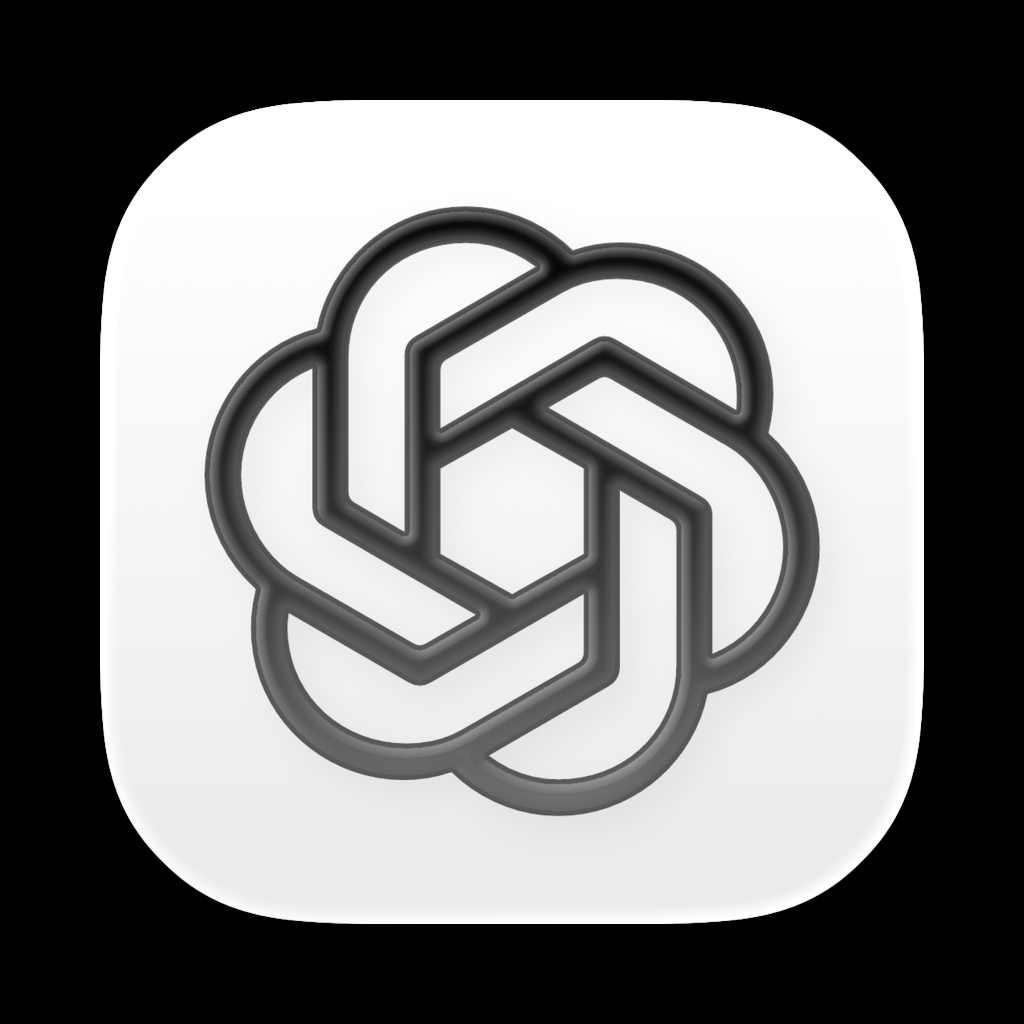


Generated Caption:
a black and white icon with a knot in the middle


In [ ]:
# ==========================================================
# IMAGE CAPTIONING USING BLIP (GOOGLE COLAB)
# ==========================================================

# Install required packages
!pip -q install transformers torch torchvision pillow accelerate

# Import libraries
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
from google.colab import files
import torch

# Select device (GPU if available)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Load pre-trained BLIP model and processor
processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

print("Model loaded successfully!")

# Upload image
print("\nUpload an image...")
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# Open image
image = Image.open(image_path).convert("RGB")

# Display image
display(image)

# Prepare image for model
inputs = processor(
    images=image,
    return_tensors="pt"
).to(device)

# Generate caption
with torch.no_grad():
    output = model.generate(
        **inputs,
        max_length=50,
        num_beams=5
    )

# Decode caption
caption = processor.decode(
    output[0],
    skip_special_tokens=True
)

print("\nGenerated Caption:")
print(caption)

# New section

In [ ]:
from google.colab import drive
drive.mount('/content/drive')